# Welcome!

## This notebook gives a simple, hands-on introduction to Shimexpy.

We’ll load a small example dataset, extract the spatial harmonics, and reconstruct the three SHI contrasts step by step. The goal is to help you understand how the workflow fits together while keeping the code clean and easy to follow.

In [20]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt

# SHIMEXPY: main processing functions
from shimexpy import (
    get_harmonics,
    get_contrasts,
    get_all_contrasts,
    load_image
)

# Visualization helpers
from skimage.exposure import equalize_hist, rescale_intensity

def percentile_eq(image, p_low=2, p_high=98):
    """
    Contrast stretching based on percentiles p_low and p_high.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image (any numeric dtype).
    p_low : float
        Lower percentile (default = 2).
    p_high : float
        Upper percentile (default = 98).

    Returns
    -------
    np.ndarray
        Image rescaled after percentile stretching.
    """
    img = image.astype(np.float32)

    # Compute percentiles
    p2, p98 = np.percentile(img, (p_low, p_high))

    # Stretch
    img_stretched = rescale_intensity(img, in_range=(p2, p98))

    return img_stretched

### Loading data

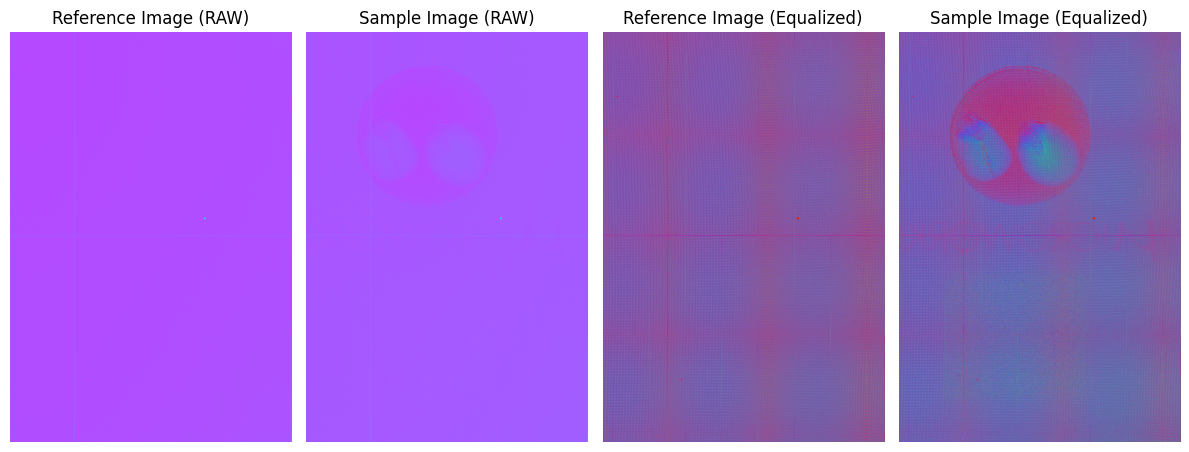

In [29]:
# Load test images
reference_img = load_image("../tests/test_reference.tif")
sample_img = load_image("../tests/test_sample.tif")

fig1, axes = plt.subplots(1, 4, figsize=(12,5))

axes[0].imshow(reference_img, cmap="cool")
axes[0].set_title("Reference Image (RAW)")
axes[0].axis("off")

axes[1].imshow(sample_img, cmap="cool")
axes[1].set_title("Sample Image (RAW)")
axes[1].axis("off")

axes[2].imshow(percentile_eq(reference_img), cmap="hsv")
axes[2].set_title("Reference Image (Equalized)")
axes[2].axis("off")

axes[3].imshow(percentile_eq(sample_img), cmap="hsv")
axes[3].set_title("Sample Image (Equalized)")
axes[3].axis("off")

fig1.tight_layout()
plt.show()

### SHI Processing Pipeline

**In this section we apply the core steps of Spatial Harmonic Imaging (SHI) to the example dataset.**

The pipeline implemented here follows exactly the workflow provided by shimexpy:
1. Flat-field correction
2. Optional cropping (ROI selection)
3. Fourier transform (CPU/GPU)
4. Harmonic extraction
5. Reference normalization
6. Contrast reconstruction

We start by computing the spatial harmonics of the reference image.

In [30]:
projected_grid = 5.0   # Replace with actual projected period of your mesh

(
    ref_abs,
    ref_scat,
    ref_dpc,
    ref_block_grid
) = get_harmonics(reference_img, projected_grid=projected_grid)

print("Reference harmonics extracted:")
print("  - Absorption shape:", ref_abs.shape)
print("  - Scattering shape:", ref_scat.shape)
print("  - DPC shape:", ref_dpc.shape)

Reference harmonics extracted:
  - Absorption shape: (872, 598)
  - Scattering shape: (8, 872, 598)
  - DPC shape: (8, 872, 598)


In [31]:
(
    abs_contrast,
    scat_contrast,
    dpc_contrast
) = get_contrasts(
    sample_img,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None   # default → skimage unwrap
)

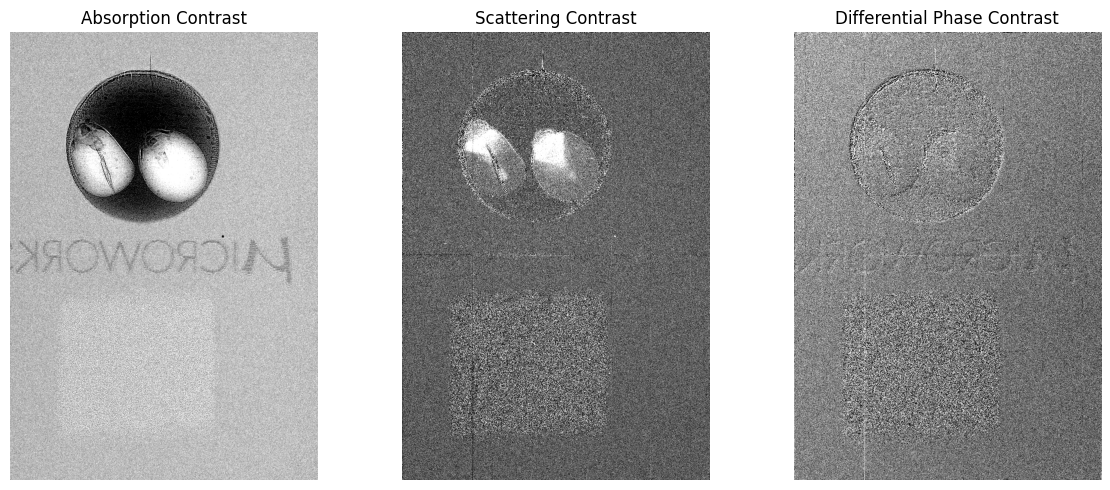

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(percentile_eq(abs_contrast), cmap='gray')
axes[0].set_title("Absorption Contrast")
axes[0].axis("off")

axes[1].imshow(percentile_eq(scat_contrast), cmap='gray')
axes[1].set_title("Scattering Contrast")
axes[1].axis("off")

axes[2].imshow(percentile_eq(dpc_contrast), cmap='gray')
axes[2].set_title("Differential Phase Contrast")
axes[2].axis("off")

plt.tight_layout()
plt.show()


### Validation and exploration of harmonics